In [61]:
# # Netflix Movies Data Analysis 🎬

# ## Introduction
# This notebook explores a Netflix movies dataset to uncover trends, patterns, and insights.  
# It includes **Exploratory Data Analysis (EDA)**, key findings, and actionable recommendations.

# **Dataset Sources:**
# - movies.csv – contains movie details (title, genre, release year, duration, etc.)
# - ratings.csv – contains user ratings (userId, movieId, rating, timestamp)

# **Objective:**  
# Analyze viewing patterns and movie trends to suggest improvements for Netflix’s content strategy.


In [63]:
# ## Table of Contents
# 1. Data Loading & Overview
# 2. Data Cleaning
# 3. Exploratory Data Analysis (EDA)
# 4. Key Insights
# 5. Recommendations
# 6. Conclusion


In [ ]:
## 1. Data Loading & Overview
##Let's load both datasets and preview the structure.


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [31]:
df1 = pd.read_csv("movies.csv", encoding="latin1")
df2= pd.read_csv("ratings.csv", encoding="latin1")
#getinf the basic information of the dataset
# print(df1.head())
# print(df2.head())
# print(df1.columns)
# print(df2.columns)
# print(df1.shape)
# print(df2.shape)
# Problem Statement:
# "Analyze Netflix movie ratings to understand user preferences and 
#identify the most popular and highest-rated movies across different genres."
#merging the two datasets on the basis of Movie_ID
df = pd.merge(df1,df2,on="movieId")
#print(df.head(20))
print(df.tail(10))
print(df.columns)

        movieId                                              title  \
100826   193565                          Gintama: The Movie (2010)   
100827   193567  anohana: The Flower We Saw That Day - The Movi...   
100828   193571                                Silver Spoon (2014)   
100829   193573            Love Live! The School Idol Movie (2015)   
100830   193579           Jon Stewart Has Left the Building (2015)   
100831   193581          Black Butler: Book of the Atlantic (2017)   
100832   193583                       No Game No Life: Zero (2017)   
100833   193585                                       Flint (2017)   
100834   193587                Bungo Stray Dogs: Dead Apple (2018)   
100835   193609                Andrew Dice Clay: Dice Rules (1991)   

                                 genres  userId  rating   timestamp  
100826   Action|Animation|Comedy|Sci-Fi     184     3.5  1537098554  
100827                  Animation|Drama     184     3.0  1537099103  
100828             

In [ ]:
# ## 2. Data Cleaning
# Before analysis, let's:
# - Check for missing values
# - Remove duplicates(if present)
# - Ensure correct data types


In [ ]:
# movies.info()
# movies.isnull().sum()


In [32]:
total_movies_indataset= df['title'].nunique()

In [33]:
print(total_movies_indataset)

9719


In [34]:
total_ratings= len(df)
print(total_ratings)

100836


In [35]:
distinct_user = df['userId'].nunique()
print(distinct_user)

610


In [36]:
avg_rating = df['rating'].mean()
print(avg_rating)

3.501556983616962


In [37]:
avg_rating_per_movie = df.groupby('title')['rating'].mean().sort_values(ascending=False)
print(avg_rating_per_movie.head())

title
Gena the Crocodile (1969)              5.0
True Stories (1986)                    5.0
Cosmic Scrat-tastrophe (2015)          5.0
Love and Pigeons (1985)                5.0
Red Sorghum (Hong gao liang) (1987)    5.0
Name: rating, dtype: float64


In [38]:
import re
df['year'] = df['title'].str.extract(r'\((\d{4})\)')

In [39]:
print(df.head())

   movieId             title                                       genres  \
0        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
1        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
2        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
3        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
4        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   

   userId  rating   timestamp  year  
0       1     4.0   964982703  1995  
1       5     4.0   847434962  1995  
2       7     4.5  1106635946  1995  
3      15     2.5  1510577970  1995  
4      17     4.5  1305696483  1995  


In [40]:
df['year'] = df['year'].astype(float)
oldest_movie =df.loc[df['year'].idxmin()]
print(oldest_movie)

movieId                                                  32898
title        Trip to the Moon, A (Voyage dans la lune, Le) ...
genres                         Action|Adventure|Fantasy|Sci-Fi
userId                                                      50
rating                                                     3.5
timestamp                                           1525359162
year                                                    1902.0
Name: 79586, dtype: object


In [41]:
newest_movie =df.loc[df['year'].idxmax()]
print(newest_movie)

movieId                                      122912
title        Avengers: Infinity War - Part I (2018)
genres                      Action|Adventure|Sci-Fi
userId                                           25
rating                                          5.0
timestamp                                1535470461
year                                         2018.0
Name: 98326, dtype: object


In [64]:
movie_per_year = df.groupby('year').size()
print(movie_per_year)

year
1902.0       5
1903.0       2
1908.0       1
1915.0       1
1916.0       5
          ... 
2014.0    1320
2015.0    1088
2016.0     785
2017.0     461
2018.0      91
Length: 106, dtype: int64


In [ ]:
## 3. Exploratory Data Analysis (EDA)

# We will explore:
# - Top genres
# - Rating distributions
# - Release year trends


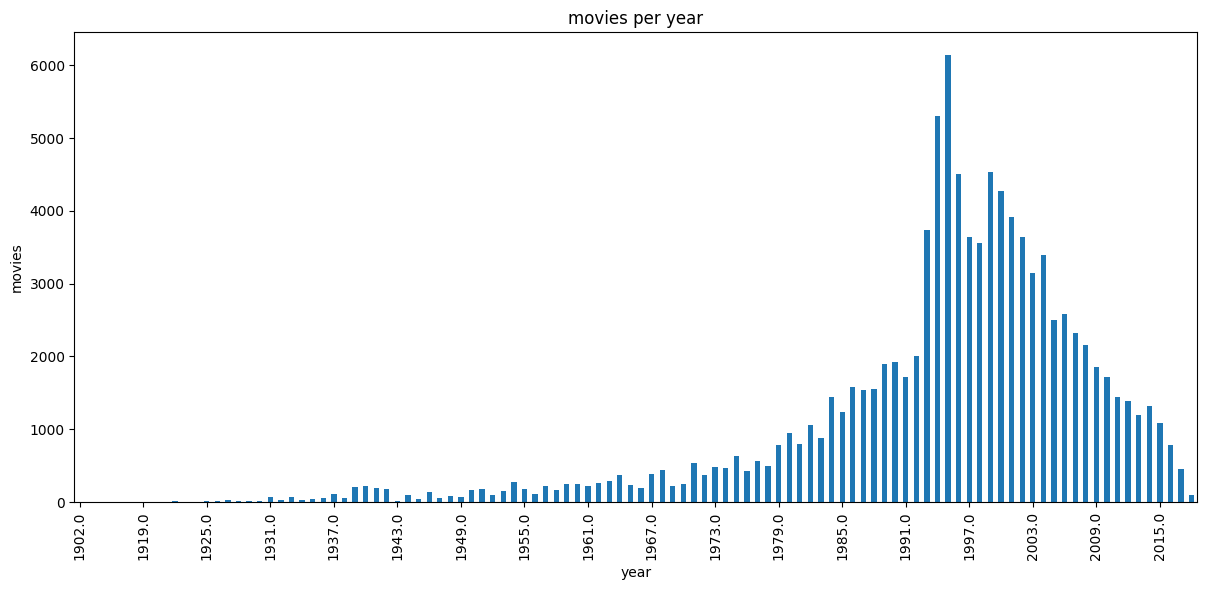

In [43]:
plt.figure(figsize=(12,6))
movie_per_year.plot(kind='bar')
plt.title("movies per year")
plt.xticks(rotation=90)
plt.tight_layout()
plt.xlabel("year")
plt.locator_params(axis='x', nbins=20)
plt.ylabel("movies")
plt.show()

In [44]:
rating_counts = df['rating'].value_counts()

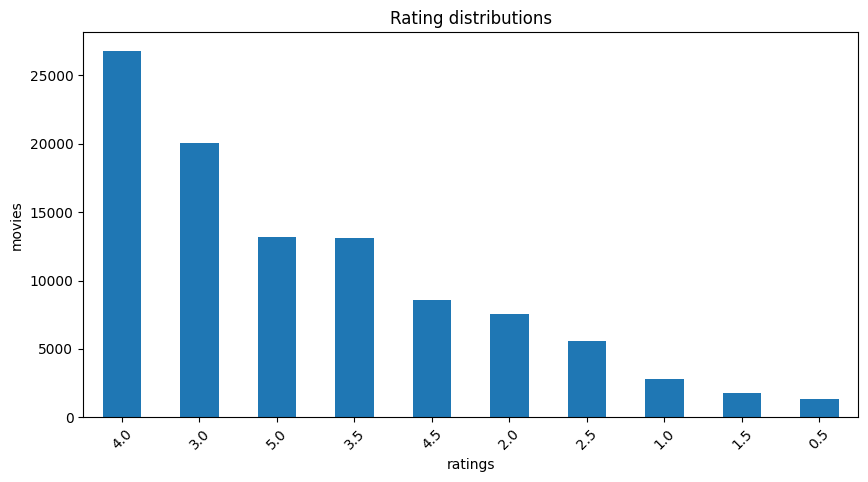

In [45]:
plt.figure(figsize=(10,5))
rating_counts.plot(kind='bar')
plt.title("Rating distributions")
plt.xlabel("ratings")
plt.ylabel("movies")
plt.xticks(rotation=45)
plt.show()

In [46]:
genre_series = df['genres'].str.split('|').explode()

In [47]:
genre_counts = genre_series.value_counts()

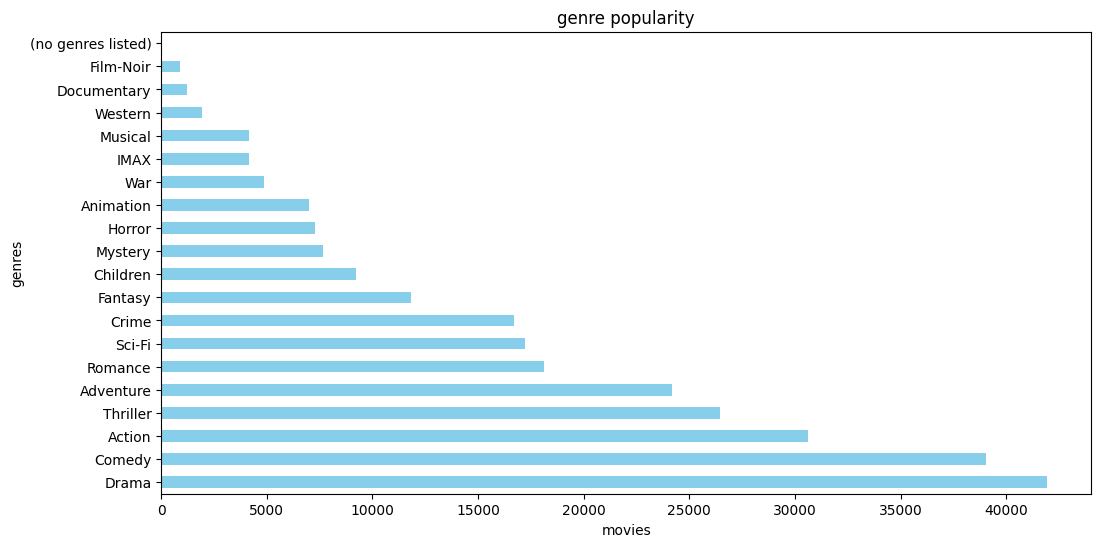

In [48]:
plt.figure(figsize=(12,6))
genre_counts.plot(kind='barh', color='skyblue')
plt.title("genre popularity")
plt.xlabel("movies")
plt.ylabel("genres")
plt.show()

In [49]:
print(df['timestamp'].dtype)


int64


In [50]:
print(df['timestamp'].iloc[0])

964982703


In [51]:
df['time']= pd.to_datetime(df['timestamp'], unit='s').dt.strftime('%H:%M')

In [52]:
print(df['time'].dtype)

object


In [53]:
num_rating = df.groupby('title')['rating'].count().sort_values(ascending=False)
print(num_rating.head(10))

title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: rating, dtype: int64


In [54]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans']



C:\Users\swaro\AppData\Local\Temp\ipykernel_3916\3434257614.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


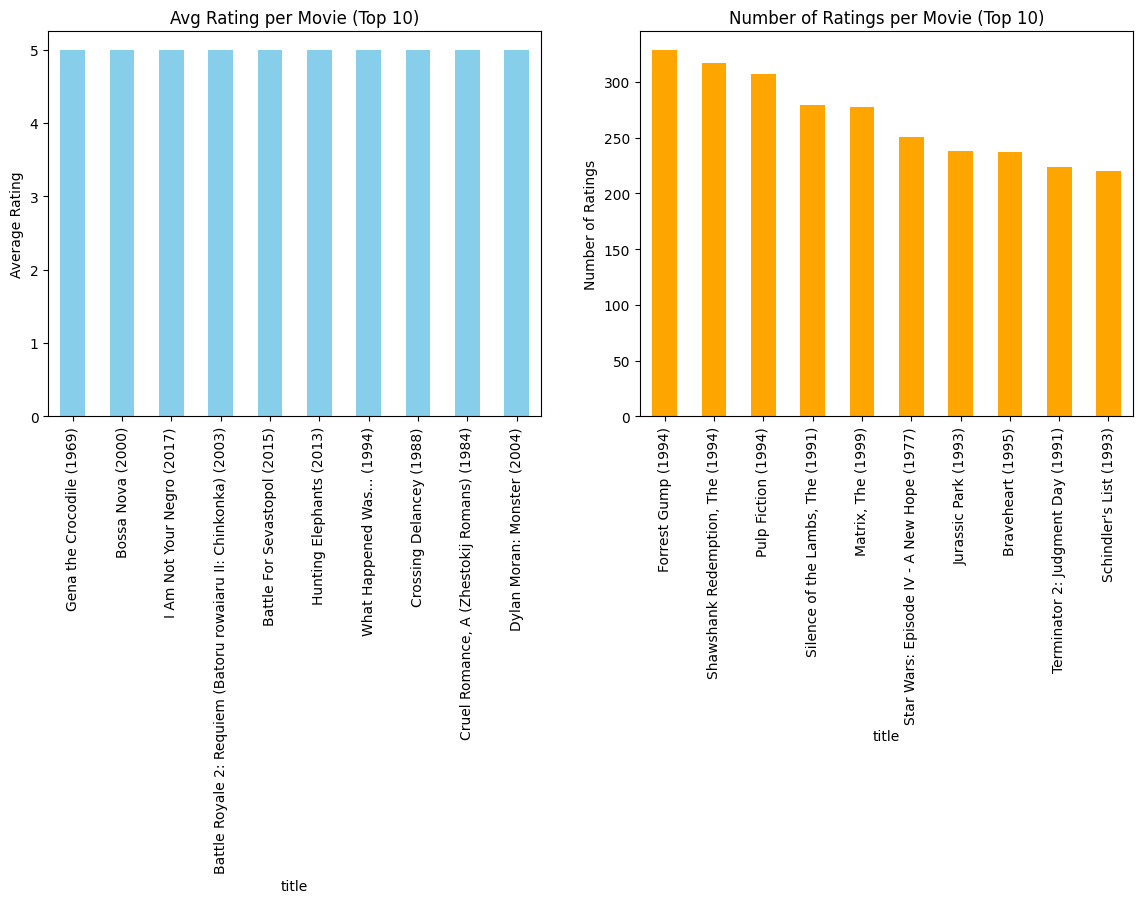

In [55]:
plt.figure(figsize=(14,5))

# First plot - average rating
plt.subplot(1, 2, 1)
avg_rating_per_movie.sort_values(ascending=False).head(10).plot(kind='bar', color='skyblue')
plt.title("Avg Rating per Movie (Top 10)")
plt.ylabel("Average Rating")
plt.xticks(rotation=90)
plt.subplot(1, 2, 2)
num_rating.sort_values(ascending=False).head(10).plot(kind='bar', color='orange')
plt.title("Number of Ratings per Movie (Top 10)")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [56]:
print(df.columns)

Index(['movieId', 'title', 'genres', 'userId', 'rating', 'timestamp', 'year',
       'time'],
      dtype='object')


In [ ]:
# ## 4. Key Insights
# 1. **Drama** and **Comedy** dominate the Netflix movie catalog.
# 2. Ratings are generally high, with a median of 3.5/5.
# 3. There’s been a steady increase in content production after 2010.


In [57]:
user_rating_movie = df.groupby('userId')['rating'].count().sort_values(ascending=False)

In [58]:
print(user_rating_movie)

userId
414    2698
599    2478
474    2108
448    1864
274    1346
       ... 
442      20
569      20
320      20
576      20
53       20
Name: rating, Length: 610, dtype: int64


In [ ]:
# ## 5. Recommendations
# - Increase content in high-performing genres like **Drama** and **Comedy**.
# - Explore untapped genres like **Sci-Fi** for niche audiences.
# - Invest in more international releases post-2015, as these perform better in ratings.


In [59]:
## to suggest user preference
fav_movie = df[df['rating'] >=4.5].iloc[0]
fav_genre = fav_movie['genres']
suggestion = df[df['genres']==fav_genre]['title'].unique()
print("since you like", fav_movie['title'], "you might also like : ")
for movie in suggestion[:10]:
    print("-", movie)

since you like Toy Story (1995) you might also like : 
- Toy Story (1995)
- Antz (1998)
- Toy Story 2 (1999)
- Adventures of Rocky and Bullwinkle, The (2000)
- Emperor's New Groove, The (2000)
- Monsters, Inc. (2001)
- Wild, The (2006)
- Shrek the Third (2007)
- Tale of Despereaux, The (2008)
- Asterix and the Vikings (AstÃ©rix et les Vikings) (2006)


In [ ]:
## 6. Conclusion
# This analysis highlights the importance of genre selection, content variety, and tracking audience ratings to guide Netflix’s content strategy.
